# Handwritten Digit Recognition
1. Preparation and Data Loading
2. Building the Neural Network
3. Training , Evaluation of the Model
4. Saving the model  

## Preparation and Data Loading

In [1]:
# general imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# imports for neural network
import torch # basic import
import torch.nn as nn 
import torch.nn.functional as F # for functions of optimizers during the eval()
import torch.optim as optim # for optimizers

# imports for the Dataset
from torchvision import transforms, datasets
from torch.utils.data import DataLoader

In [2]:
# Hyperparameters
batch_size = 64
image_size = 28 * 28 # MNIST images are 28x28 pixels
num_classes = 10  # digits 0-9

In [3]:
# Mean and std of MNIST Dataset already calculated
mean = 0.1307
std = 0.3081

Defining the transformation pipeline

1. ToTensor() converts the PIL (Python Imaging Library, Pillow) image (0-255) to a FloatTensor (0.0 - 1.0)
2. Normalize() standardizes the data using the calculated mean and standard deviation for MNIST

In [4]:
transform = transforms.Compose([
    transforms.RandomRotation(10), # rotate the image by +- 10 degrees
    transforms.RandomAffine(0, translate = (0.1, 0.1)), # Shifting digits
    transforms.ToTensor(),
    transforms.Normalize((mean, ), (std, )) #MNIST specific values
])
# using Compose I am creating a sequence of trasformations that to be applied to every image loaded from the dataset


Load the dataset

In [5]:
# we will download the train dataset and apply the transformation on it
train_dataset = datasets.MNIST(
    root = "C:/Users/Shashank/Desktop/My Folder/My-Projects/Number_Rec/data",
    train = True, 
    transform = transform,
    download = True
)

# Similarly we will follow the same for the test dataset
test_dataset = datasets.MNIST(
    root = "C:/Users/Shashank/Desktop/My Folder/My-Projects/Number_Rec/data",
    train = False,
    download = True,
    transform = transform
)


In [6]:
# checking the total number of the samples
print(f"Training dataset size : {len(train_dataset)} images")
print(f"Test dataset size : {len(test_dataset)} images")

Training dataset size : 60000 images
Test dataset size : 10000 images


Perform the split (train and validation dataset) on the original train_dataset (60,000 images)

In [7]:
from torch.utils.data import random_split

# defining the sizes
train_size = 50000
vaild_size = 10000

train_subset, vaild_subset = random_split(train_dataset, [train_size, vaild_size])

Creating DataLoaders

In [8]:
train_loader = DataLoader(train_subset, batch_size= batch_size, shuffle = True)
val_loader = DataLoader(vaild_subset, batch_size = batch_size, shuffle = True)
test_loader = DataLoader(test_dataset, batch_size = batch_size, shuffle = False)

In [9]:
print(f"Total training batches : {len(train_loader)}")
print(f"Total Validation batches : {len(val_loader)}")
print(f"Total testing batches : {len(test_loader)}")

Total training batches : 782
Total Validation batches : 157
Total testing batches : 157


Here the train_loader is an "iterable" (like a generator), we can't index it like a list.
Instead, we use next(iter()) to grab the very first batch.

In [10]:
# Grab one batch from the DataLoader

# Images will be a tensor of shape [batch_size, 1, 28, 28] & labels will be tensor of shape [batch_size].
images, labels = next(iter(train_loader))

# Just checking the dimensions
print(f"Batch images shape : {images.shape}")
print(f"Batch label size : {labels.shape}")

Batch images shape : torch.Size([64, 1, 28, 28])
Batch label size : torch.Size([64])


In [11]:
# Checking the range of the pixel values (verifying the normalization)
print(f"Minimum pixel value in batch : {images.min().item() : .4f}")
print(f"Maximum pixel value in batch : {images.max().item() : .4f}")

Minimum pixel value in batch : -0.4242
Maximum pixel value in batch :  2.8215


In [12]:
print(f"Labels in this batch : {labels}")

Labels in this batch : tensor([6, 8, 3, 1, 7, 6, 8, 8, 7, 3, 9, 8, 3, 0, 5, 9, 5, 4, 5, 0, 1, 1, 0, 5,
        9, 2, 0, 5, 4, 7, 5, 7, 9, 3, 6, 4, 4, 0, 2, 2, 0, 4, 1, 6, 3, 1, 2, 0,
        8, 9, 8, 5, 3, 1, 6, 2, 5, 6, 3, 7, 8, 8, 2, 1])


Visualization

As the image dimensions are (Batch_size, Channels, Height, Width).
here Channel is 1 because MNIST images are grayscale (not RGB).  

In [13]:
from torchvision.utils import make_grid

In [14]:
# Creating a grid of images
grid_img = make_grid(images[:16], nrow = 4, normalize = True)
# As my kernel is dying because the plt.imshow is very specific to this range 0 - 1.
# So I am Un-normalizing it.

Breaking down the above code :

1. **The Input** : *images[:16]*, 
When we pull a batch from our *train_loader*, the *images* tensor has the shape (64, 1, 28, 28).
    * The Slice [:16] : We are telling PyTorch to take only the first 16 images from that batch.
    * The shape : This sub-tensor now has the shape(16, 1, 28, 28).
2. **The Parameter** : *nrow = 4*, 
This tells the function how many images we want in each row of our grid.
    * Since we have 16 images total and we want 4 images per row, the function will automatically calculate that it needs 4 rows ($16 / 4 = 4$).
    * This results in a nice $4 \times 4$ square grid.
3. **The Output** : *grid_img*, 
The output of *make_grid* is a single 3D tensor.
    * It combines all those small $28 \times 28$ images into one large image.
    * It also adds a small amount of "padding" (black pixels) between the images by default so they don't blend into each other.

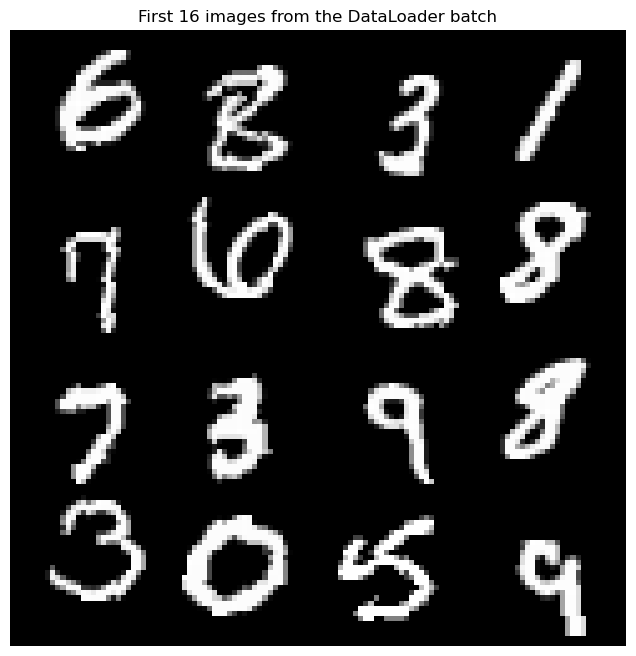

In [15]:
# Convert from PyTorch Tensor (C, H, W) -> (0, 1, 2) to Matplotlib format (H, W, C) -> (1, 2, 0) using .permute(1, 2, 0)

plt.figure(figsize = (8, 8))
plt.imshow(grid_img.permute(1, 2, 0).numpy(), cmap = 'gray') # Converting it to numpy for safer rendering
plt.title("First 16 images from the DataLoader batch")
plt.axis('off')
plt.show()

My Kernel is crashing for Visualizing the batch, So I will try for a single image.

In [16]:
print(f"Shape of the single image : {images[0].shape}")

Shape of the single image : torch.Size([1, 28, 28])


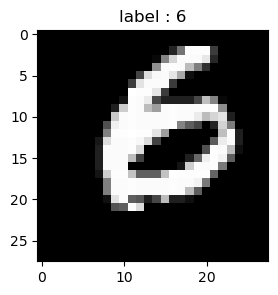

In [17]:
single_img = images[0] # shape (1, 28, 28)
single_img_squeezed = single_img.squeeze().numpy() # Shape (28, 28)

plt.figure(figsize = (3,3))
plt.imshow(single_img_squeezed, cmap = 'gray')
plt.title(f"label : {labels[0].item()}")
plt.show()

# Building the Neural Network (CNN)

I will implement this architecture for this task.
$$\text{Input} \xrightarrow{28 \times 28} \text{Conv Layer} \rightarrow \text{ReLU} \rightarrow \text{Max Pooling} \rightarrow \text{Conv Layer} \rightarrow \text{ReLU} \rightarrow \text{Max Pooling} \rightarrow \text{Flatten} \rightarrow \text{Linear Layer} \rightarrow \text{Output}$$

1. **Conv Layers**: Use *nn.Conv2d* to extract features (like edges and shapes).

2. **Pooling Layers**: Use *nn.MaxPool2d* to reduce the spatial size of the feature maps, which reduces computational load and helps the model become more robust to slight variations in the input image.

3. **Flatten**: After the final pooling layer, you must Flatten the 3D output into a 1D vector so it can be passed to the final Linear layer.

4. **Final Linear Layer**: A final fully connected layer maps the extracted features to the 10 final classes.

In [18]:
# implementing CNN

class CNN_Model(nn.Module):
    def __init__(self):
        super(CNN_Model, self).__init__()
        # First Convolutional Block
        self.conv1 = nn.Conv2d(in_channels = 1, out_channels = 10, stride = 1, kernel_size = 5)
        # in_channel(1) -> (applying 10 filters) -> out_channel(10)
        # Output should be after conv1 [batch, 10, 24, 24]
        self.pool = nn.MaxPool2d(2, 2)
        # Output after Pooling layer [10, 12, 12]

        # Second Convolutional Block
        self.conv2 = nn.Conv2d(in_channels = 10, out_channels = 20, stride = 1, kernel_size = 5)
        # Output shape after conv2 [20, 8, 8]
        # Output after Pooling layer [20, 4, 4] --> flatten it (20*4*4) = 320 parameters

        # Fully Connected (linear) layer
        self.fc = nn.Linear(in_features = 320, out_features = 10) # as output size is 10 (classes from 0 - 9)

    def forward(self, x):
        # Applying first Convolution block = convolution -> ReLu -> Pooling
        x = self.pool(F.relu(self.conv1(x)))

        # Applying second Convolution block = Convolution -> ReLu -> Pooling
        x = self.pool(F.relu(self.conv2(x)))

        # Flatten the 3D tensor into 1D vector
        x = x.view(-1, 20*4*4)
        #-1 means the batch dimension is kept as it

        # Applying the final fully connected layer
        x = self.fc(x)

        return x # the output is the unnormalized log-probabilities

Instantiate the Model

In [19]:
model = CNN_Model()
print(model)

CNN_Model(
  (conv1): Conv2d(1, 10, kernel_size=(5, 5), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(10, 20, kernel_size=(5, 5), stride=(1, 1))
  (fc): Linear(in_features=320, out_features=10, bias=True)
)


# Training the Model

Setting-up Loss and Optimizer

As it is a **classification** tasks like digit recognition, *Cross Entropy Loss* is the standard choice. We will use *Adam Optimizer* for efficient weight updates.

In [20]:
# Loss Function CrossEntropy includes Softmax internally
criterion = nn.CrossEntropyLoss()

# Optimizer
optimizer = optim.Adam(model.parameters(), lr = 0.001)

Training loop

In [21]:
num_epochs = 10
training_history = {'train_loss' : [], 'val_loss' : []}
print("Start Training ...")

for epoch in range(num_epochs):

    # Training Phase
    model.train()
    running_loss = 0.0

    for images, labels in train_loader :
        optimizer.zero_grad() # setting all the gradients to zero for new gradients

        # Forward Pass
        output = model(images)
        loss = criterion(output, labels) #Calculating the loss
        loss.backward() # Backwardpropagation to calculate the gradients
        optimizer.step() # update the weights

        running_loss += loss.item()

    epoch_loss = running_loss / len(train_subset)
    training_history['train_loss'].append(epoch_loss)

    # Validation Phase
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            output = model(images)
            _, predication = torch.max(output.data, 1)
            total += labels.size(0)
            correct += (predication == labels).sum().item()
    
    val_accuracy = correct / total * 100
    training_history['val_loss'].append(val_accuracy)

    print(f"Epoch [{epoch + 1} / {num_epochs}] , Train Loss : {epoch_loss : .4f} , Val Accuracy : {val_accuracy : .2f}%")
    


Start Training ...
Epoch [1 / 10] , Train Loss :  0.0074 , Val Accuracy :  93.76%
Epoch [2 / 10] , Train Loss :  0.0027 , Val Accuracy :  95.35%
Epoch [3 / 10] , Train Loss :  0.0020 , Val Accuracy :  96.73%
Epoch [4 / 10] , Train Loss :  0.0017 , Val Accuracy :  96.78%
Epoch [5 / 10] , Train Loss :  0.0015 , Val Accuracy :  97.28%
Epoch [6 / 10] , Train Loss :  0.0013 , Val Accuracy :  96.96%
Epoch [7 / 10] , Train Loss :  0.0012 , Val Accuracy :  97.59%
Epoch [8 / 10] , Train Loss :  0.0011 , Val Accuracy :  97.36%
Epoch [9 / 10] , Train Loss :  0.0011 , Val Accuracy :  97.66%
Epoch [10 / 10] , Train Loss :  0.0010 , Val Accuracy :  97.96%


In [22]:
# Now testing the model on the test dataset
model.eval()
test_correct = 0
test_total = 0

with torch.no_grad():
    for images, labels in test_loader:
        output = model(images)
        _, predication = torch.max(output.data, 1)
        test_total += labels.size(0)
        test_correct += (predication == labels).sum().item()

test_accuracy = 100 * test_correct / test_total
print(f"Final Accuracy on the 10,000 Test Images : {test_accuracy : .2f}%")

Final Accuracy on the 10,000 Test Images :  98.19%


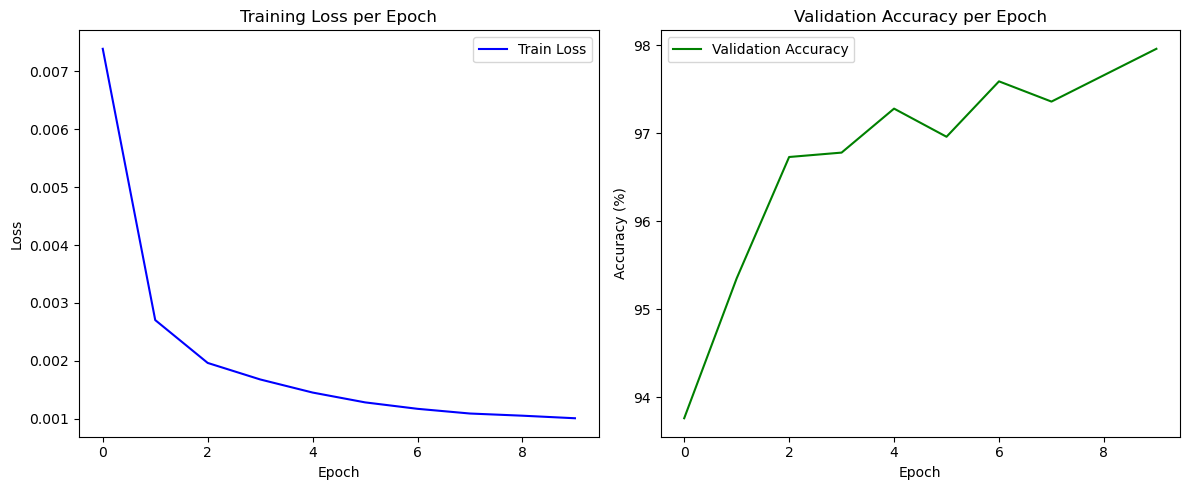

In [23]:
# Visualizing the training History
plt.figure(figsize = (12, 5))

# Plot Training Loss
plt.subplot(1, 2, 1)
plt.plot(training_history['train_loss'], label = 'Train Loss', color = 'blue')
plt.title("Training Loss per Epoch")
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Plot Validation Accuracy
plt.subplot(1, 2, 2)
plt.plot(training_history['val_loss'], label = "Validation Accuracy", color = 'green')
plt.title("Validation Accuracy per Epoch")
plt.xlabel('Epoch')
plt.ylabel("Accuracy (%)")
plt.legend()

plt.tight_layout()
plt.show()

# Saving Model

In [24]:
# Saving the model weights
MODEL_PATH = "CNN_MNIST_model.pth"
torch.save(model.state_dict(), MODEL_PATH)

print(f"Model weights saved to {MODEL_PATH}")

Model weights saved to CNN_MNIST_model.pth


In [25]:
import joblib

# Saving the metadata and the preprocessing objects
metadata = {
    'classes' : [str(i) for i in range(10)],
    'training_history' : training_history,
    'normalization_stats' : {'mean' : mean, 'std' : std}
}

joblib.dump(metadata, 'model_metadata.pkl')
print("Metadata saved using joblib.")

Metadata saved using joblib.
